# 递归 Burg LPC Vocoder 测试

使用递归 Burg 算法（**B(0)=1.0 初始化**）进行 LPC 声码器测试。

## 原理

LPC 声码器将语音信号分解为**声道滤波器参数**（LPC 系数）和**激励信号**两部分：

1. **分析端**：递归 Burg 逐样本递推计算反射系数 $k_m$（B(0)=1.0 初始化），通过 Levinson 递推转为 LPC 系数 $a_m$
2. **激励生成**：从残差中提取基频 F0，在相应位置生成 $\delta$ 脉冲串
3. **合成端**：将 $\delta$ 串通过全极点合成滤波器 $1/A(z)$ 重建语音

$$
H(z) = \frac{1}{A(z)} = \frac{1}{1 + a_1 z^{-1} + a_2 z^{-2} + \cdots + a_P z^{-P}}
$$

## 输入 / 载波

| 项目 | 内容 |
|------|------|
| 输入音频 | `wormhole.wav` 前 1 秒（48 kHz） |
| 载波信号 | $\delta$ 串（基频同步脉冲串） |
| LPC 阶数 | $P = 16$（人声建模） |

## 参考

- [burg_compare.ipynb](burg_compare.ipynb) — 分块 Burg vs 递归 Burg LPC 分析对比
- [recursive_burg_study.ipynb](recursive_burg_study.ipynb) — 递归 Burg 初始化策略研究（B(0)=1.0）

In [92]:
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
from scipy.signal import freqz, lfilter
from IPython.display import Audio, display
import os

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False
np.random.seed(42)

print("库导入完成")

库导入完成


---
## 1. 读取 wormhole.wav 前 1 秒

In [93]:
# ------------------------------------------------------------
# 读取 wormhole.wav 前 1 秒
# ------------------------------------------------------------
WAV_PATH = r"c:\Users\Kawai\Desktop\a5632645\qwqdsp\qwqdsp\tests\work_dir\input\wormhole.wav"
x_full, fs = sf.read(WAV_PATH)

# 转为单声道
if x_full.ndim > 1:
    x_full = x_full[:, 0]

# 截取前 1 秒
N = int(1.0 * fs)
x = x_full[:N].copy()
t = np.arange(N) / fs

print(f"采样率: {fs} Hz")
print(f"长度: {N} 样本 ({N/fs:.2f} 秒)")
print(f"信号范围: [{x.min():.4f}, {x.max():.4f}]")

# 预加重
pre_emph = 0.97
x_pre = np.append(x[0], x[1:] - pre_emph * x[:-1])

采样率: 48000 Hz
长度: 48000 样本 (1.00 秒)
信号范围: [-0.5369, 0.4222]


---
## 2. 算法函数定义

In [94]:
# ------------------------------------------------------------
# 2a. 分块 Burg（参考）
# ------------------------------------------------------------
def block_burg(x, order):
    """标准分块 Burg 法，返回 LPC 系数、残差、反射系数"""
    N = len(x)
    f = x.copy().astype(np.float64)
    b = x.copy().astype(np.float64)
    k = np.zeros(order)
    a = np.array([1.0])
    for m in range(order):
        num = 2.0 * np.sum(f[m+1:] * b[m:N-1])
        den = np.sum(f[m+1:]**2 + b[m:N-1]**2)
        k[m] = -num / den if den > 1e-30 else 0.0
        f_next = f.copy()
        b_next = b.copy()
        f_next[m+1:] = f[m+1:] + k[m] * b[m:N-1]
        b_next[m+1:] = b[m:N-1] + k[m] * f[m+1:]
        f, b = f_next, b_next
        a = np.pad(a, (0, 1), mode='constant')
        a_prev = a.copy()   # 保存旧系数（a[-1]=0，刚 padded 的占位）
        a[-1] = k[m]        # a_{m+1} = k_m
        for i in range(1, m + 1):
            # a_m(i) = a_{m-1}(i) + k_m * a_{m-1}(m - i + 1)
            a[i] = a_prev[i] + k[m] * a_prev[m + 1 - i]
    return a, f.copy(), k


# ------------------------------------------------------------
# 2b. 递归 Burg（B(0)=1.0 初始化）
# ------------------------------------------------------------
def recursive_burg_one(x, order, lam=0.995, eps=1e-6):
    """
    递归 Burg 法，B(0)=1.0 初始化。

    第 m 级格型滤波器的递归更新：
        A_m(t) = lambda * A_m(t-1) + f_{m-1}[t] * b_{m-1}[t-1]
        B_m(t) = lambda * B_m(t-1) + f_{m-1}[t]**2 + b_{m-1}[t-1]**2
        k_m(t) = -2 * A_m(t) / B_m(t)

    B(0) = 1.0 使初始阶段 k_m 不会因分母过小而剧烈波动，
    同时避免 eps 小常数导致的早期过冲。
    """
    N = len(x)
    dtype = np.float64
    f_curr = np.zeros(order + 1, dtype=dtype)
    b_prev_arr = np.zeros(order + 1, dtype=dtype)
    b_curr = np.zeros(order + 1, dtype=dtype)
    A = np.zeros(order, dtype=dtype)
    B = np.full(order, eps, dtype=dtype)   # B(0) = eps（小常数，逐采样积累）
    k = np.zeros(order, dtype=dtype)
    k_history = np.zeros((N, order), dtype=dtype)
    e = np.zeros(N, dtype=dtype)

    for t in range(N):
        f_curr[0] = x[t]
        b_curr[0] = x[t]
        for m in range(order):
            f_m1_t = f_curr[m]
            b_m1_t1 = b_prev_arr[m]
            A[m] = lam * A[m] + f_m1_t * b_m1_t1
            B[m] = lam * B[m] + f_m1_t**2 + b_m1_t1**2
            k[m] = -2.0 * A[m] / B[m] if B[m] > 1e-30 else 0.0
            k[m] = np.clip(k[m], -0.999, 0.999)
            f_curr[m + 1] = f_m1_t + k[m] * b_m1_t1
            b_curr[m + 1] = b_m1_t1 + k[m] * f_m1_t
        k_history[t] = k.copy()
        e[t] = f_curr[order]
        b_prev_arr[:order] = b_curr[:order]
    return k_history, e


# ------------------------------------------------------------
# 2c. Levinson 递推：反射系数 -> LPC 系数
# ------------------------------------------------------------
def levinson_from_k(k):
    """从反射系数计算 LPC 系数 [1, a1, ..., aP]"""
    P = len(k)
    a = np.ones(P + 1)
    for m in range(P):
        k_m = k[m]
        a_prev = a.copy()
        a[m + 1] = k_m
        for i in range(1, m + 1):
            a[i] = a_prev[i] + k_m * a_prev[m - i + 1]
    return a


# ------------------------------------------------------------
# 2d. 基频检测（自相关法）
# ------------------------------------------------------------
def pitch_autocorr(signal, fs, f0_min=50, f0_max=500):
    """
    自相关法基频检测。

    在 [f0_min, f0_max] 范围内搜索自相关峰值，
    返回基频估计值（Hz），无声段返回 0。
    """
    N = len(signal)
    r = np.correlate(signal, signal, mode='full')
    r = r[N-1:]  # 只取正延迟
    r /= r[0] if r[0] > 1e-30 else 1.0

    min_lag = int(fs / f0_max)
    max_lag = int(fs / f0_min)
    if max_lag >= len(r):
        max_lag = len(r) - 1

    segment = r[min_lag:max_lag + 1]
    peak_idx = np.argmax(segment)
    peak_val = segment[peak_idx]

    if peak_val < 0.3:
        return 0.0

    lag = min_lag + peak_idx
    f0 = fs / lag
    return f0


# ------------------------------------------------------------
# 2e. LPC 合成滤波器（时不变）
# ------------------------------------------------------------
def lpc_synth(excitation, a):
    """
    用 LPC 全极点滤波器 1/A(z) 合成信号（时不变版本）。
    """
    return lfilter([1.0], a, excitation)


# ------------------------------------------------------------
# 2f. 时变 LPC 合成滤波器（逐样本递推）
# ------------------------------------------------------------
def lpc_synth_tv(excitation, a_history):
    """
    时变 LPC 合成滤波器：每样本使用不同的 LPC 系数。

    实现直接 IIR 递推：
        y[n] = x[n] - a1*y[n-1] - a2*y[n-2] - ... - aP*y[n-P]

    参数:
        excitation: 激励信号 (N,)
        a_history: LPC 系数历史 (N, P+1)，每行 [1, a1, ..., aP]
    返回:
        合成信号 (N,)
    """
    N = len(excitation)
    P = a_history.shape[1] - 1
    y = np.zeros(N, dtype=np.float64)
    for n in range(N):
        a = a_history[n]
        y[n] = excitation[n]
        for m in range(1, P + 1):
            if n >= m:
                y[n] -= a[m] * y[n - m]
    return y


# ------------------------------------------------------------
# 2g. LPC 频谱包络
# ------------------------------------------------------------
def lpc_envelope(a, fs, n_fft=4096):
    """从 LPC 系数计算频谱包络（dB）"""
    w, h = freqz(1.0, a, worN=n_fft, fs=fs)
    env_db = 20.0 * np.log10(np.abs(h) + 1e-30)
    return w, env_db


print("所有函数定义完成")

所有函数定义完成


---
## 3. 递归 Burg LPC 分析（全信号 + 分帧参考）

In [95]:
# ------------------------------------------------------------
# 参数
# ------------------------------------------------------------
P = 36              # LPC 阶数
tau = 0.010         # 遗忘时间 10ms
lam = np.exp(-1.0 / (tau * fs))

frame_ms = 30       # 帧长 30ms（仅分块 Burg 参考需要）
hop_ms = 10         # 帧移 10ms
frame_len = int(frame_ms * fs / 1000)
hop_len = int(hop_ms * fs / 1000)
n_frames = 1 + (N - frame_len) // hop_len

print(f"LPC 阶数: P = {P}")
print(f"遗忘时间: τ = {tau*1000:.0f} ms  (λ = {lam:.6f})")
print(f"等效记忆: ≈ {1/(1-lam):.0f} 采样")
print(f"帧长: {frame_len} 采样 ({frame_ms}ms) [分块参考用]")
print(f"帧移: {hop_len} 采样 ({hop_ms}ms)")
print(f"总帧数: {n_frames}")


# ------------------------------------------------------------
# 3a. 递归 Burg：全信号一次性处理（逐样本递推）
# ------------------------------------------------------------
# 递归 Burg 是 sample-by-sample 的，不需要分帧/OLA。
# 一次跑完整个信号，每样本都有对应的反射系数和残差。
k_history, e_rec = recursive_burg_one(x_pre, P, lam=lam)
# k_history: (N, P) — 每样本的反射系数
# e_rec: (N,) — 每样本的残差（预测误差）

# 将每样本的反射系数转为 LPC 系数（全信号逐点）
a_history = np.zeros((N, P + 1))
for n in range(N):
    a_history[n] = levinson_from_k(k_history[n])

# 为与分块 Burg 对比，按帧中心采样 LPC 系数
t_frames = (np.arange(n_frames) * hop_len + frame_len / 2).astype(int)
t_frames = np.clip(t_frames, 0, N - 1)
a_rec_frames = a_history[t_frames]
k_rec_frames = k_history[t_frames]

print(f"递归 Burg 全信号分析完成 ({N} 样本)")


# ------------------------------------------------------------
# 3b. 分块 Burg LPC 分析（分帧参考）
# ------------------------------------------------------------
a_block_frames = np.zeros((n_frames, P + 1))
k_block_frames = np.zeros((n_frames, P))
e_block_frames = np.zeros(N)
win = np.hanning(frame_len)

for idx in range(n_frames):
    s = idx * hop_len
    frame = x_pre[s:s + frame_len] * win
    a_f, e_f, k_f = block_burg(frame, P)
    a_block_frames[idx] = a_f
    k_block_frames[idx] = k_f
    e_block_frames[s:s + frame_len] += e_f * win

print(f"分块 Burg LPC 分析完成 ({n_frames} 帧)")

LPC 阶数: P = 36
遗忘时间: τ = 10 ms  (λ = 0.997919)
等效记忆: ≈ 481 采样
帧长: 1440 采样 (30ms) [分块参考用]
帧移: 480 采样 (10ms)
总帧数: 98


递归 Burg 全信号分析完成 (48000 样本)
分块 Burg LPC 分析完成 (98 帧)


---
## 4. 基频检测与 δ 串载波生成

In [96]:
# ------------------------------------------------------------
# 4a. 逐帧基频检测 + 清/浊音判断
# ------------------------------------------------------------
# 递归 Burg 残差已被高度白化（AR 预测去相关），自相关峰值不明显。
# 改用预加重信号做基频检测，周期性更清晰。
f0_per_frame = np.zeros(n_frames)
for idx in range(n_frames):
    s = idx * hop_len
    frame = x_pre[s:s + frame_len] * win
    f0 = pitch_autocorr(frame, fs, f0_min=60, f0_max=500)
    f0_per_frame[idx] = f0

# 清/浊音判断
voiced_mask = f0_per_frame > 0.0

# 基频平滑：中值滤波消除帧间抖动
from scipy.signal import medfilt
f0_smooth = f0_per_frame.copy()
if np.sum(voiced_mask) > 0:
    f0_smooth[voiced_mask] = medfilt(f0_smooth[voiced_mask], kernel_size=5)

print(f"F0 平滑前: [{f0_per_frame[f0_per_frame > 0].min():.1f}, {f0_per_frame.max():.1f}] Hz")
print(f"F0 平滑后: [{f0_smooth[f0_smooth > 0].min():.1f}, {f0_smooth.max():.1f}] Hz")
print(f"浊音/清音帧: {np.sum(voiced_mask)}/{np.sum(~voiced_mask)} / {n_frames}")


# ------------------------------------------------------------
# 4b. 生成混合激励信号 + 幅度包络
# ------------------------------------------------------------
np.random.seed(42)
excitation = np.zeros(N)

for idx in range(n_frames):
    s = idx * hop_len
    e_frame = min(s + frame_len, N)
    frame_len_actual = e_frame - s
    seg = slice(s, e_frame)

    if voiced_mask[idx]:
        # 浊音：delta 脉冲串（使用平滑后的 F0）
        f0 = f0_smooth[idx]
        period = int(fs / f0)
        first_pulse = s + (period - (s % period)) % period
        pulse_positions = np.arange(first_pulse, e_frame, period)
        frame_exc = np.zeros(frame_len_actual)
        for p in pulse_positions:
            if 0 <= p < N:
                frame_exc[p - s] = 1.0
    else:
        # 清音：白噪声
        frame_exc = np.random.randn(frame_len_actual)

    # 幅度包络：对齐到原始信号该帧 RMS
    frame_signal = x[s:e_frame]
    rms_signal = np.sqrt(np.mean(frame_signal**2) + 1e-30)
    rms_exc = np.sqrt(np.mean(frame_exc**2) + 1e-30)
    if rms_exc > 1e-30:
        frame_exc *= rms_signal / rms_exc

    # 叠加到总激励（加窗 OLA）
    excitation[seg] += frame_exc * win[:frame_len_actual]

# 提取脉冲位置（用于绘图）
pulse_indices = np.where(excitation > 0.5 * np.max(np.abs(excitation)))[0]
print(f"delta 脉冲数: {len(pulse_indices)}")
print(f"激励 RMS / 原始 RMS: {np.sqrt(np.mean(excitation**2)) / np.sqrt(np.mean(x**2)):.4f}")

F0 平滑前: [122.4, 489.8] Hz
F0 平滑后: [125.7, 466.0] Hz
浊音/清音帧: 85/13 / 98
delta 脉冲数: 43
激励 RMS / 原始 RMS: 1.1767


---
## 5. LPC 合成（δ 串激励 → 语音）

In [97]:
# ------------------------------------------------------------
# 5a. 递归 Burg → 混合激励 LPC 合成（逐样本时变滤波）
# ------------------------------------------------------------
# 递归 Burg 是 sample-by-sample 的，合成也应该是 sample-by-sample：
# 每样本用该时刻的 LPC 系数 a_history[t] 做 1/A_t(z) 时变滤波。
# 激励信号: 浊音段 delta 脉冲串 + 清音段白噪声
synth_rec_burg = lpc_synth_tv(excitation, a_history)
print(f"递归 Burg Vocoder 合成完成（时变滤波，{N} 样本）")


# ------------------------------------------------------------
# 5b. 分块 Burg → 混合激励 LPC 合成（帧 + OLA）
# ------------------------------------------------------------
# 分块 Burg 是帧级别的，合成也沿用帧处理 + OLA。
synth_block_burg = np.zeros(N)

for idx in range(n_frames):
    s = idx * hop_len
    e_frame = min(s + frame_len, N)

    frame_exc = excitation[s:e_frame].copy()
    a_frame = a_block_frames[idx]
    frame_synth = lfilter([1.0], a_frame, frame_exc)

    synth_block_burg[s:e_frame] += frame_synth * win[:e_frame - s]

print(f"分块 Burg Vocoder 合成完成")


# ------------------------------------------------------------
# 5c. 残差激励 LPC 合成（参考：用递归 Burg 残差本身做激励）
# ------------------------------------------------------------
# "理想"情况——用原始残差做时变滤波激励，验证合成滤波器正确性
# 残差 e_rec 是递归 Burg 全信号分析的结果，(N,)
# 用每样本的 LPC 系数 a_history 做时变滤波
synth_resid_exc = lpc_synth_tv(e_rec, a_history)
print(f"残差激励 LPC 合成完成（时变滤波参考）")

递归 Burg Vocoder 合成完成（时变滤波，48000 样本）
分块 Burg Vocoder 合成完成
残差激励 LPC 合成完成（时变滤波参考）


---
## 6. 可视化对比

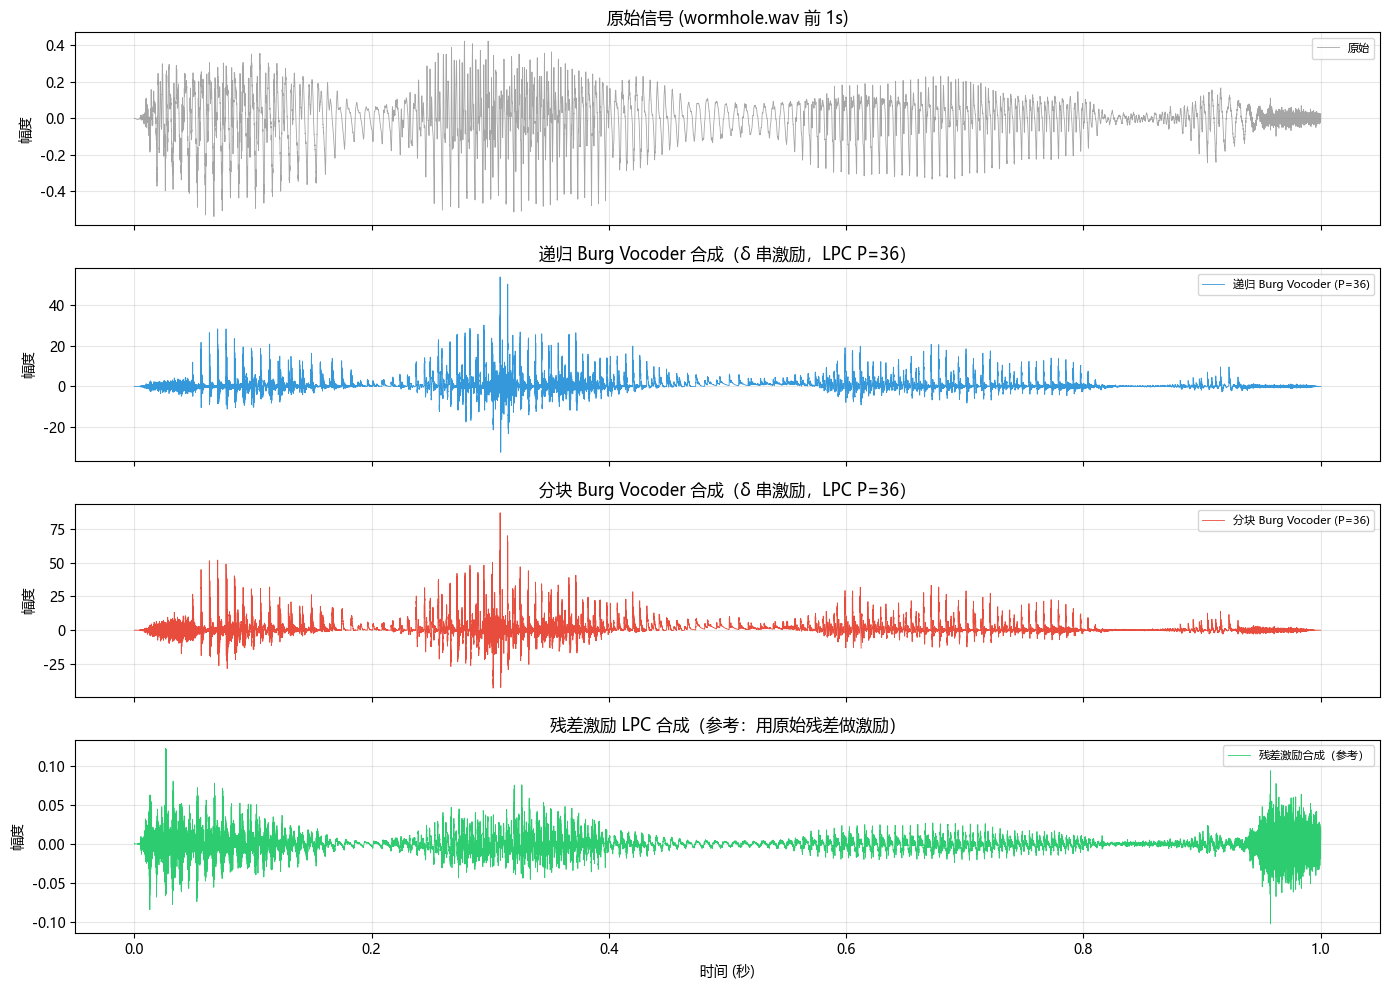

In [98]:
# ------------------------------------------------------------
# 6a. 波形对比：原始 vs δ 串合成（递归 Burg）
# ------------------------------------------------------------
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

# 原始波形
ax1 = axes[0]
ax1.plot(t, x, color='gray', linewidth=0.6, alpha=0.7, label='原始')
ax1.set_ylabel('幅度')
ax1.set_title('原始信号 (wormhole.wav 前 1s)')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=8)

# 递归 Burg Vocoder 合成
ax2 = axes[1]
ax2.plot(t, synth_rec_burg, color='#3498db', linewidth=0.6, label=f'递归 Burg Vocoder (P={P})')
ax2.set_ylabel('幅度')
ax2.set_title(f'递归 Burg Vocoder 合成（δ 串激励，LPC P={P}）')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=8)

# 分块 Burg Vocoder 合成
ax3 = axes[2]
ax3.plot(t, synth_block_burg, color='#e74c3c', linewidth=0.6, label=f'分块 Burg Vocoder (P={P})')
ax3.set_ylabel('幅度')
ax3.set_title(f'分块 Burg Vocoder 合成（δ 串激励，LPC P={P}）')
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=8)

# 残差激励合成（理想参考）
ax4 = axes[3]
ax4.plot(t, synth_resid_exc, color='#2ecc71', linewidth=0.6, label='残差激励合成（参考）')
ax4.set_ylabel('幅度')
ax4.set_title('残差激励 LPC 合成（参考：用原始残差做激励）')
ax4.set_xlabel('时间 (秒)')
ax4.grid(True, alpha=0.3)
ax4.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 7. 频谱分析与激励可视化

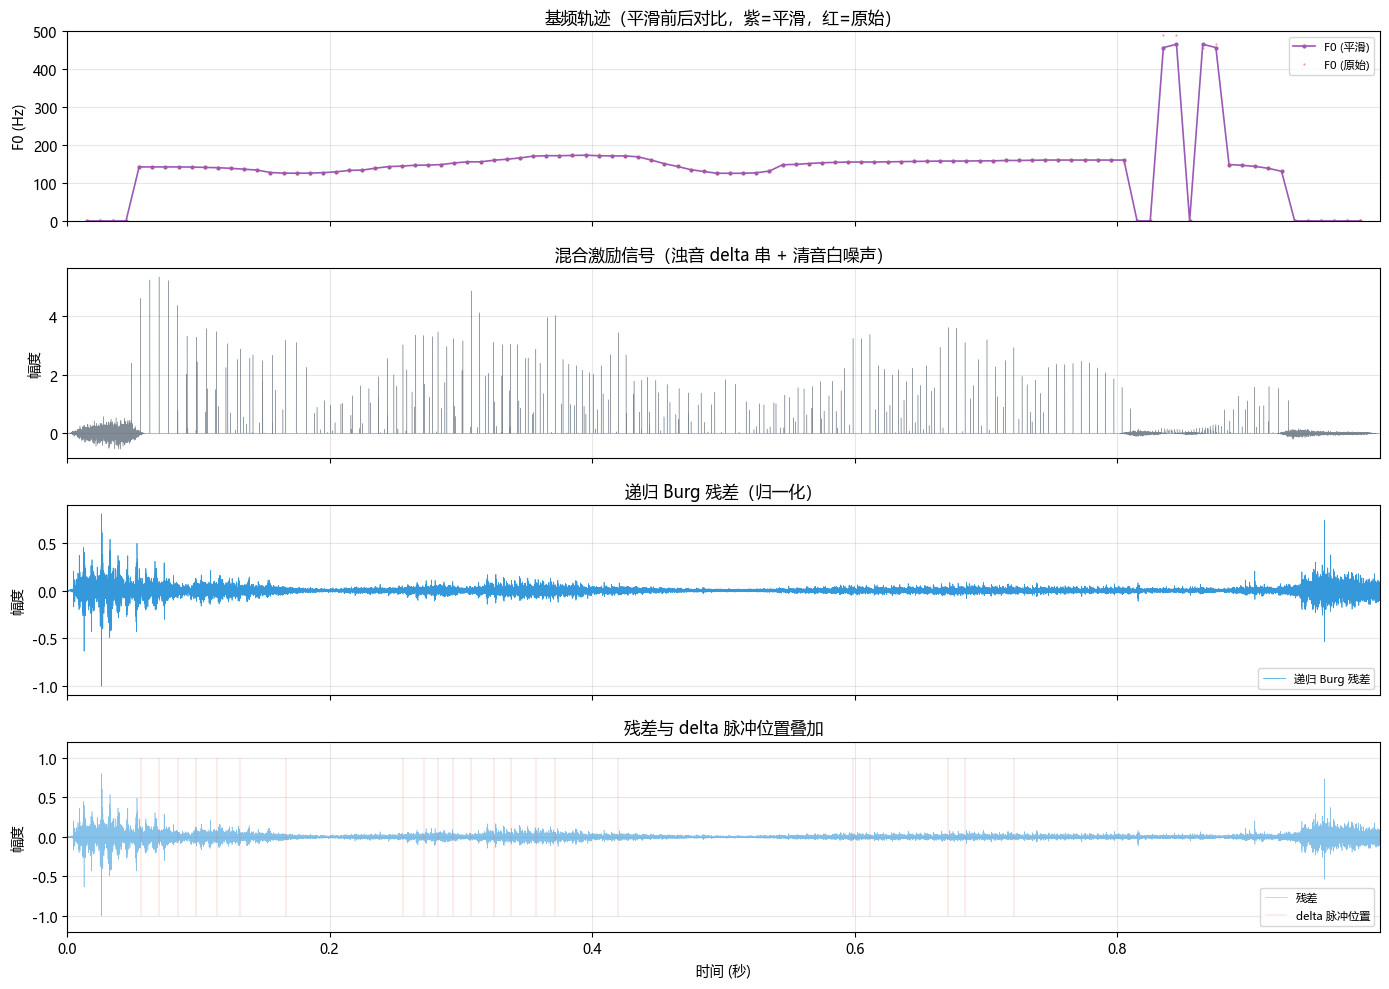

In [99]:
# ------------------------------------------------------------
# 7a. F0 轨迹 + 混合激励 + 残差
# ------------------------------------------------------------
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

# F0 轨迹（平滑前后对比）
ax1 = axes[0]
t_f0 = (np.arange(n_frames) * hop_len + frame_len / 2) / fs
ax1.plot(t_f0, f0_smooth, 'o-', color='#9b59b6', linewidth=1.2, markersize=2, label='F0 (平滑)')
ax1.plot(t_f0, f0_per_frame, '.', color='#e74c3c', markersize=1.5, alpha=0.4, label='F0 (原始)')
ax1.axhline(y=0, color='gray', linewidth=0.5, linestyle=':', alpha=0.5)
ax1.set_ylabel('F0 (Hz)')
ax1.set_title('基频轨迹（平滑前后对比，紫=平滑，红=原始）')
ax1.set_ylim(0, 500)
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# 混合激励（浊音 delta 串 + 清音噪声）
ax2 = axes[1]
ax2.plot(t, excitation, color='#2c3e50', linewidth=0.3, alpha=0.6)
ax2.set_ylabel('幅度')
ax2.set_title('混合激励信号（浊音 delta 串 + 清音白噪声）')
ax2.set_xlim(0, t[-1])
ax2.grid(True, alpha=0.3)

# 递归 Burg 残差
ax3 = axes[2]
e_rec_norm = e_rec / (np.max(np.abs(e_rec)) + 1e-30)
ax3.plot(t, e_rec_norm, color='#3498db', linewidth=0.5, label='递归 Burg 残差')
ax3.set_ylabel('幅度')
ax3.set_title('递归 Burg 残差（归一化）')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

# 残差 + delta 脉冲位置叠加
ax4 = axes[3]
ax4.plot(t, e_rec_norm, color='#3498db', linewidth=0.4, alpha=0.6, label='残差')
if len(pulse_indices) > 0:
    step = max(1, len(pulse_indices) // 20)
    ax4.vlines(t[pulse_indices[::step]], -1, 1, color='#e74c3c', linewidth=0.3, alpha=0.5, label='delta 脉冲位置')
ax4.set_ylabel('幅度')
ax4.set_title('残差与 delta 脉冲位置叠加')
ax4.set_xlabel('时间 (秒)')
ax4.set_ylim(-1.2, 1.2)
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 8. 频谱包络对比

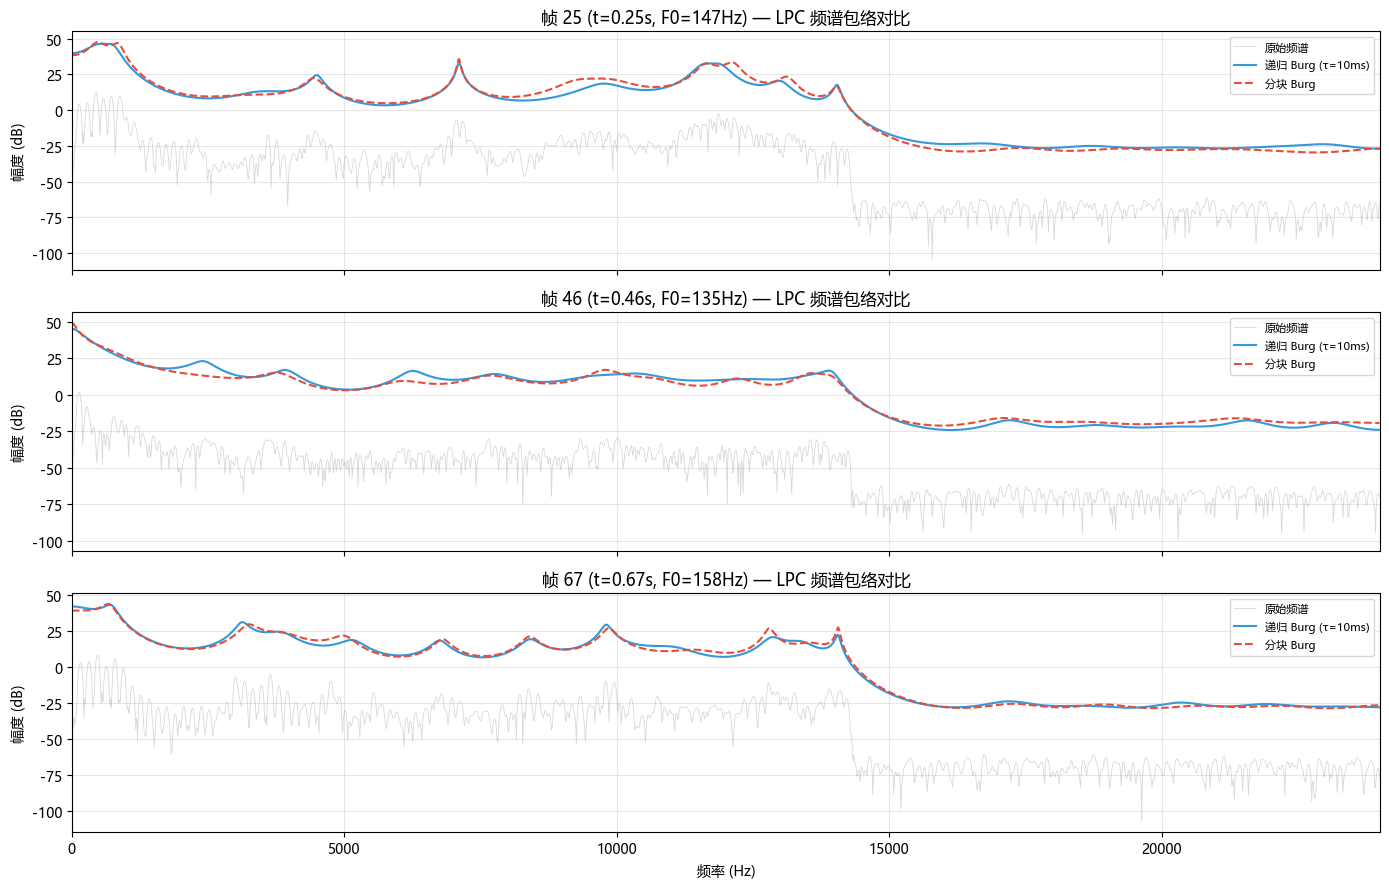

In [100]:
# ------------------------------------------------------------
# 8a. LPC 频谱包络对比（选有声帧）
# ------------------------------------------------------------
voiced_frames = np.where(f0_per_frame > 50)[0]
if len(voiced_frames) > 0:
    sel_frames = [voiced_frames[len(voiced_frames) // 4],
                  voiced_frames[len(voiced_frames) // 2],
                  voiced_frames[3 * len(voiced_frames) // 4]]

    n_fft_env = 4096
    fig, axes = plt.subplots(len(sel_frames), 1, figsize=(14, 9), sharex=True)

    for i, fidx in enumerate(sel_frames):
        ax = axes[i]
        s = fidx * hop_len

        frame_x = x_pre[s:s + frame_len] * win
        spec_x = np.abs(np.fft.rfft(frame_x, n=n_fft_env))
        spec_x_db = 20 * np.log10(spec_x + 1e-30)
        freq_axis = np.fft.rfftfreq(n_fft_env, d=1/fs)

        ax.plot(freq_axis, spec_x_db, color='gray', alpha=0.3, linewidth=0.6, label='原始频谱')
        w_rec, env_rec = lpc_envelope(a_rec_frames[fidx], fs, n_fft_env)
        ax.plot(w_rec, env_rec, color='#3498db', linewidth=1.5, label=f'递归 Burg (τ={tau*1000:.0f}ms)')
        w_block, env_block = lpc_envelope(a_block_frames[fidx], fs, n_fft_env)
        ax.plot(w_block, env_block, color='#e74c3c', linewidth=1.5, linestyle='--', label='分块 Burg')

        ax.set_ylabel('幅度 (dB)')
        f0_here = f0_per_frame[fidx]
        ax.set_title(f'帧 {fidx} (t={s/fs:.2f}s, F0={f0_here:.0f}Hz) — LPC 频谱包络对比')
        ax.set_xlim(0, fs / 2)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel('频率 (Hz)')
    plt.tight_layout()
    plt.show()
else:
    print("没有找到有声帧，跳过频谱包络对比")

---
## 9. 语谱图对比

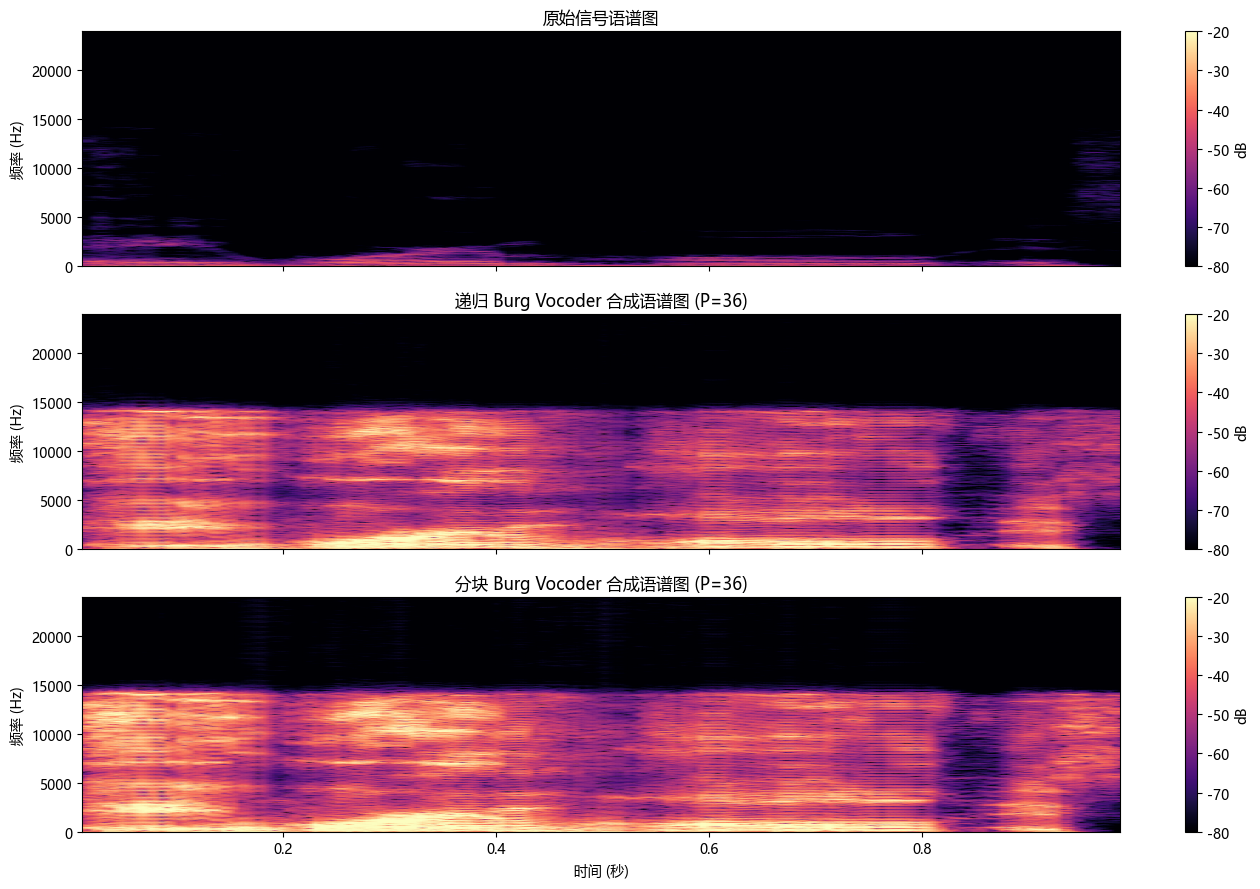

In [101]:
# ------------------------------------------------------------
# 9a. 语谱图对比：原始 vs 递归 Burg Vocoder vs 分块 Burg Vocoder
# ------------------------------------------------------------
from scipy.signal import spectrogram

n_fft_spec = 1024
hop_len_spec = 256

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

def plot_spectrogram(ax, signal, fs, title, vmin=-80, vmax=-20):
    f_spec, t_spec, Sxx = spectrogram(signal, fs, nperseg=n_fft_spec,
                                       noverlap=n_fft_spec - hop_len_spec)
    Sxx_db = 10 * np.log10(Sxx + 1e-30)
    im = ax.pcolormesh(t_spec, f_spec, Sxx_db, shading='gouraud',
                       cmap='magma', vmin=vmin, vmax=vmax)
    ax.set_ylabel('频率 (Hz)')
    ax.set_title(title)
    ax.set_ylim(0, fs / 2)
    return im

im1 = plot_spectrogram(axes[0], x, fs, '原始信号语谱图')
fig.colorbar(im1, ax=axes[0], label='dB')

im2 = plot_spectrogram(axes[1], synth_rec_burg, fs,
                       f'递归 Burg Vocoder 合成语谱图 (P={P})')
fig.colorbar(im2, ax=axes[1], label='dB')

im3 = plot_spectrogram(axes[2], synth_block_burg, fs,
                       f'分块 Burg Vocoder 合成语谱图 (P={P})')
fig.colorbar(im3, ax=axes[2], label='dB')

axes[-1].set_xlabel('时间 (秒)')
plt.tight_layout()
plt.show()

---
## 10. 反射系数可视化

C:\Users\Kawai\AppData\Local\Temp\ipykernel_18960\1249629001.py:33: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


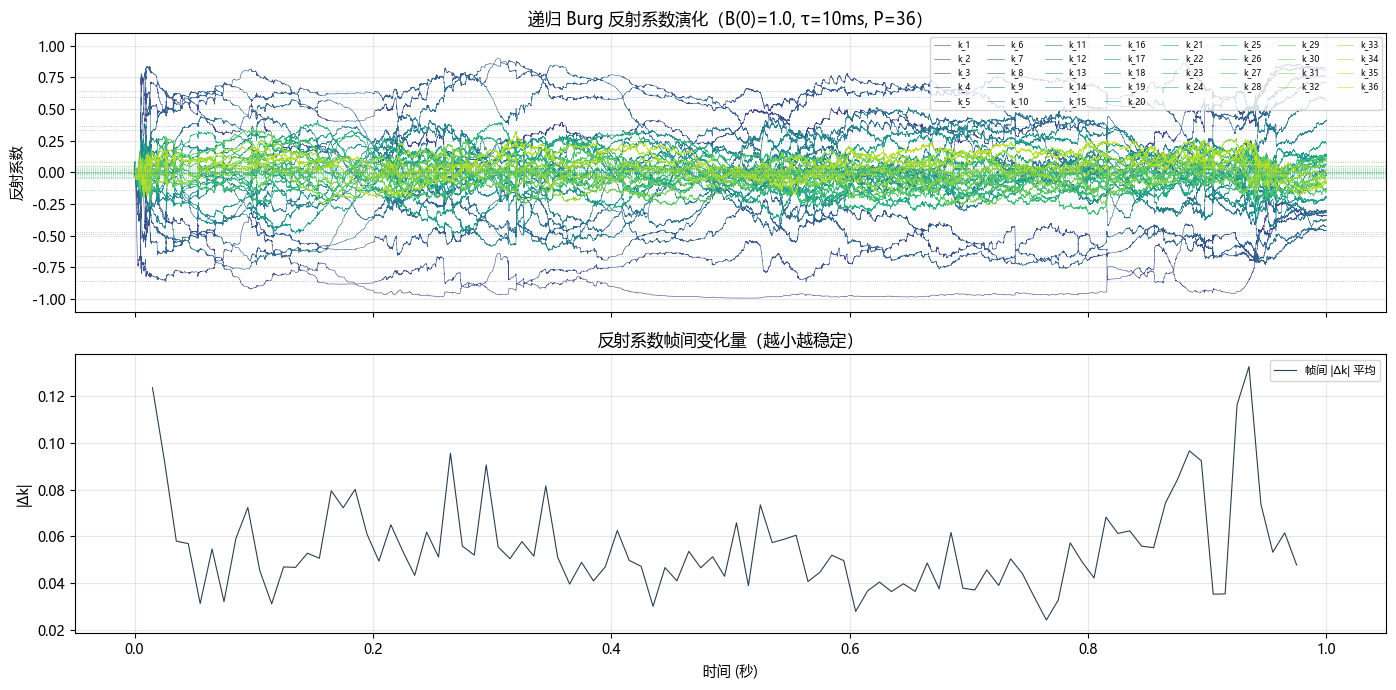

反射系数帧间平均变化: 0.0554
最大 |k_m|: 0.9917
反射系数越界 (|k|>=1) 帧数: 0 / 98


In [102]:
# ------------------------------------------------------------
# 10a. 递归 Burg 反射系数随时间演化
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# 递归 Burg 反射系数
ax1 = axes[0]
colors_k = plt.cm.viridis(np.linspace(0.2, 0.9, P))
for m in range(P):
    ax1.plot(t, k_history[:, m], linewidth=0.4, color=colors_k[m], label=f'k_{m+1}')
# 叠加分块 Burg 的反射系数（水平虚线）
for m in range(P):
    ax1.axhline(y=np.mean(k_block_frames[:, m]), color=colors_k[m],
                linewidth=0.6, linestyle=':', alpha=0.4)
ax1.set_ylabel('反射系数')
ax1.set_title(f'递归 Burg 反射系数演化（B(0)=1.0, τ={tau*1000:.0f}ms, P={P}）')
ax1.set_ylim(-1.1, 1.1)
ax1.legend(fontsize=6, ncol=8)
ax1.grid(True, alpha=0.3)

# 反射系数稳定度：各帧间的 k 变化
ax2 = axes[1]
k_diff = np.diff(k_rec_frames, axis=0)
k_fluct = np.mean(np.abs(k_diff), axis=1)
t_kdiff = (np.arange(len(k_fluct)) * hop_len + frame_len / 2) / fs
ax2.plot(t_kdiff, k_fluct, color='#2c3e50', linewidth=0.8, label='帧间 |Δk| 平均')
ax2.set_ylabel('|Δk|')
ax2.set_title('反射系数帧间变化量（越小越稳定）')
ax2.set_xlabel('时间 (秒)')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 定量统计
print(f"反射系数帧间平均变化: {np.mean(k_fluct):.4f}")
print(f"最大 |k_m|: {np.max(np.abs(k_rec_frames)):.4f}")
print(f"反射系数越界 (|k|>=1) 帧数: {np.sum(np.any(np.abs(k_rec_frames) >= 1.0, axis=1))} / {n_frames}")

---
## 11. 音频播放对比

In [103]:
# ------------------------------------------------------------
# 音频播放
# ------------------------------------------------------------
# 归一化合成信号到 [-1, 1]
synth_rec_norm = synth_rec_burg / (np.max(np.abs(synth_rec_burg)) + 1e-30)
synth_block_norm = synth_block_burg / (np.max(np.abs(synth_block_burg)) + 1e-30)
synth_resid_norm = synth_resid_exc / (np.max(np.abs(synth_resid_exc)) + 1e-30)

print("原始信号（前 1 秒）:")
display(Audio(x, rate=fs))

print("递归 Burg Vocoder 合成（δ 串激励）:")
display(Audio(synth_rec_norm, rate=fs))

print("分块 Burg Vocoder 合成（δ 串激励）:")
display(Audio(synth_block_norm, rate=fs))

print("残差激励 LPC 合成（参考）:")
display(Audio(synth_resid_norm, rate=fs))

print("混合激励信号（浊音 δ 串 + 清音噪声）:")
display(Audio(excitation, rate=fs))

原始信号（前 1 秒）:


递归 Burg Vocoder 合成（δ 串激励）:


分块 Burg Vocoder 合成（δ 串激励）:


残差激励 LPC 合成（参考）:


混合激励信号（浊音 δ 串 + 清音噪声）:


---
## 12. 定量评价

In [104]:
# ------------------------------------------------------------
# 12a. 定量评价指标
# ------------------------------------------------------------
# SNR（以原始信号为参考）
def compute_snr(original, reconstructed):
    noise = original - reconstructed
    snr = 10 * np.log10(np.sum(original**2) / (np.sum(noise**2) + 1e-30))
    return snr

# 只计算有声段的 SNR（能量较大的区域）
energy_thresh = 0.1 * np.max(x**2)
voiced_mask = np.convolve(x**2, np.ones(1000)/1000, mode='same') > energy_thresh

snr_rec = compute_snr(x[voiced_mask], synth_rec_burg[voiced_mask])
snr_block = compute_snr(x[voiced_mask], synth_block_burg[voiced_mask])
snr_resid = compute_snr(x[voiced_mask], synth_resid_exc[voiced_mask])

print("=== 定量评价（有声段） ===")
print(f"递归 Burg Vocoder SNR:    {snr_rec:.2f} dB")
print(f"分块 Burg Vocoder SNR:    {snr_block:.2f} dB")
print(f"残差激励 LPC SNR（参考）:  {snr_resid:.2f} dB")

# LPC 系数帧间一致性（递归 Burg vs 分块 Burg）
coeff_diff = np.mean(np.abs(a_rec_frames - a_block_frames))
print(f"\n递归/分块 Burg LPC 系数平均绝对差异: {coeff_diff:.4f}")

# 残差 vs 激励的相关性
cross_corr = np.correlate(e_rec, excitation, mode='full')
peak_corr = np.max(np.abs(cross_corr)) / (np.sqrt(np.sum(e_rec**2) * np.sum(excitation**2)) + 1e-30)
print(f"残差与激励最大互相关系数: {peak_corr:.4f}")

# 反射系数稳定性
k_std_frame = np.std(k_rec_frames, axis=0)
print(f"\n反射系数帧间标准差（P={P}）:")
for m in range(P):
    print(f"  k_{m+1}: {k_std_frame[m]:.4f}")
print(f"  平均: {np.mean(k_std_frame):.4f}")

=== 定量评价（有声段） ===
递归 Burg Vocoder SNR:    -29.67 dB
分块 Burg Vocoder SNR:    -34.04 dB
残差激励 LPC SNR（参考）:  0.25 dB

递归/分块 Burg LPC 系数平均绝对差异: 0.8096
残差与激励最大互相关系数: 0.0300

反射系数帧间标准差（P=36）:
  k_1: 0.1937
  k_2: 0.1608
  k_3: 0.1427
  k_4: 0.1071
  k_5: 0.1281
  k_6: 0.1303
  k_7: 0.1769
  k_8: 0.2757
  k_9: 0.3004
  k_10: 0.2478
  k_11: 0.2682
  k_12: 0.2424
  k_13: 0.1712
  k_14: 0.2273
  k_15: 0.1376
  k_16: 0.1183
  k_17: 0.1996
  k_18: 0.1429
  k_19: 0.1607
  k_20: 0.1339
  k_21: 0.1212
  k_22: 0.1692
  k_23: 0.1387
  k_24: 0.0880
  k_25: 0.1339
  k_26: 0.0896
  k_27: 0.0769
  k_28: 0.1274
  k_29: 0.0928
  k_30: 0.0758
  k_31: 0.1015
  k_32: 0.0552
  k_33: 0.1026
  k_34: 0.0807
  k_35: 0.0944
  k_36: 0.0879
  平均: 0.1473


---
## 13. 固定频率 δ 串载波测试（音乐声码器应用）

本节测试将载波替换为**固定频率的 δ 脉冲串**（而非从输入信号检测 F0），模拟音乐场景中声码器的典型用法。

### 音乐声码器原理

在音乐制作中，声码器通常将**人声**作为调制信号（提取频谱包络），将**合成器/乐器**作为载波信号：
- 载波使用固定频率（音符）的脉冲串 / 锯齿波 / 噪声
- LPC 分析提取人声的声道滤波器参数 $1/A(z)$
- 载波通过 $1/A(z)$ 滤波器，获得"会说话"的乐器音色

### 测试计划

| 载波频率 | 对应音符 | 说明 |
|---------|---------|------|
| 110 Hz | A2 | 低音区 |
| 220 Hz | A3 | 中音区 |
| 440 Hz | A4 | 标准音 |
| 880 Hz | A5 | 高音区 |
| 混合 | 和弦模拟 | 多个频率同时发声 |


In [105]:
# ------------------------------------------------------------
# 13a. 固定频率 δ 串生成函数
# ------------------------------------------------------------
def fixed_freq_delta_train(freq_hz, n_samples, fs):
    """生成固定频率的 δ 脉冲串"""
    period = int(fs / freq_hz)
    exc = np.zeros(n_samples)
    exc[::period] = 1.0
    return exc


def fixed_freq_excitation(freq_hz, n_samples, fs, frame_energy):
    """
    生成幅度包络对齐的固定频率 δ 串。

    将原始信号的帧能量包络施加到固定频率 δ 串上，
    使合成结果保留原始信号的动态节奏。
    """
    exc = fixed_freq_delta_train(freq_hz, n_samples, fs)
    # 分帧施加幅度包络
    frame_len_e = frame_len
    hop_len_e = hop_len
    win_e = np.hanning(frame_len_e)
    n_frames_e = 1 + (n_samples - frame_len_e) // hop_len_e

    exc_env = np.zeros(n_samples)
    for idx in range(n_frames_e):
        s = idx * hop_len_e
        e_frame = min(s + frame_len_e, n_samples)
        frame_len_actual = e_frame - s
        seg = slice(s, e_frame)

        frame_exc = exc[seg].copy()
        rms_target = frame_energy[idx]
        rms_exc = np.sqrt(np.mean(frame_exc**2) + 1e-30)
        if rms_exc > 1e-30 and rms_target > 1e-30:
            frame_exc *= rms_target / rms_exc

        exc_env[seg] += frame_exc * win_e[:frame_len_actual]
    return exc_env


# 计算原始信号各帧 RMS 作为幅度包络参考
np.random.seed(42)
frame_rms = np.zeros(n_frames)
for idx in range(n_frames):
    s = idx * hop_len
    e_frame = min(s + frame_len, N)
    frame_signal = x[s:e_frame]
    frame_rms[idx] = np.sqrt(np.mean(frame_signal**2) + 1e-30)

# 测试的固定频率（音乐音符）
test_freqs = {
    "A2 (110 Hz)": 110.0,
    "A3 (220 Hz)": 220.0,
    "A4 (440 Hz)": 440.0,
    "A5 (880 Hz)": 880.0,
}

# 生成各频率的载波并进行 LPC 合成
synth_fixed = {}
exc_fixed = {}
for label, freq in test_freqs.items():
    print(f"生成载波: {label} ({freq:.1f} Hz) ...", end=" ")
    exc_f = fixed_freq_excitation(freq, N, fs, frame_rms)
    exc_fixed[label] = exc_f
    synth_f = lpc_synth_tv(exc_f, a_history)
    synth_fixed[label] = synth_f
    print(f"完成")

# ----- 混合频率（和弦模拟）-----
def mixed_freq_excitation(freqs_hz, amps, n_samples, fs, frame_energy):
    """多个频率同时发声，模拟和弦载波"""
    n_freqs = len(freqs_hz)
    exc = np.zeros(n_samples)
    for f, a in zip(freqs_hz, amps):
        period = max(1, int(fs / f))
        e = np.zeros(n_samples)
        e[::period] = a
        exc += e
    exc /= n_freqs  # 归一化幅度

    # 施加幅度包络
    frame_len_e = frame_len
    hop_len_e = hop_len
    win_e = np.hanning(frame_len_e)
    n_frames_e = 1 + (n_samples - frame_len_e) // hop_len_e

    exc_env = np.zeros(n_samples)
    for idx in range(n_frames_e):
        s = idx * hop_len_e
        e_frame = min(s + frame_len_e, n_samples)
        frame_len_actual = e_frame - s
        seg = slice(s, e_frame)

        frame_exc = exc[seg].copy()
        rms_target = frame_energy[idx]
        rms_exc = np.sqrt(np.mean(frame_exc**2) + 1e-30)
        if rms_exc > 1e-30 and rms_target > 1e-30:
            frame_exc *= rms_target / rms_exc

        exc_env[seg] += frame_exc * win_e[:frame_len_actual]
    return exc_env


chord_freqs = [220.0, 277.18, 329.63]   # A3, C#4, E4 → Am 和弦
chord_amps = [1.0, 0.7, 0.5]
exc_chord = mixed_freq_excitation(chord_freqs, chord_amps, N, fs, frame_rms)
synth_chord = lpc_synth_tv(exc_chord, a_history)
print(f"和弦载波 (Am: A3+C#4+E4) 合成完成")


# ------------------------------------------------------------
# 13b. 分块 Burg 固定频率合成（帧+OLA 对比）
# ------------------------------------------------------------
synth_fixed_block = {}

for label, freq in test_freqs.items():
    print(f"分块 Burg 合成: {label} ({freq:.1f} Hz) ...", end=" ")
    exc_f = exc_fixed[label]
    synth = np.zeros(N)
    for idx in range(n_frames):
        s = idx * hop_len
        e_frame = min(s + frame_len, N)
        frame_exc = exc_f[s:e_frame].copy()
        a_frame = a_block_frames[idx]
        frame_synth = lfilter([1.0], a_frame, frame_exc)
        synth[s:e_frame] += frame_synth * win[:e_frame - s]
    synth_fixed_block[label] = synth
    print(f"完成")

# 分块 Burg 和弦合成
synth_chord_block = np.zeros(N)
for idx in range(n_frames):
    s = idx * hop_len
    e_frame = min(s + frame_len, N)
    frame_exc = exc_chord[s:e_frame].copy()
    a_frame = a_block_frames[idx]
    frame_synth = lfilter([1.0], a_frame, frame_exc)
    synth_chord_block[s:e_frame] += frame_synth * win[:e_frame - s]
print(f"分块 Burg 和弦载波合成完成")

print("\n所有固定频率载波 Vocoder 合成完成")

生成载波: A2 (110 Hz) (110.0 Hz) ... 完成
生成载波: A3 (220 Hz) (220.0 Hz) ... 完成
生成载波: A4 (440 Hz) (440.0 Hz) ... 完成
生成载波: A5 (880 Hz) (880.0 Hz) ... 完成
和弦载波 (Am: A3+C#4+E4) 合成完成
分块 Burg 合成: A2 (110 Hz) (110.0 Hz) ... 完成
分块 Burg 合成: A3 (220 Hz) (220.0 Hz) ... 完成
分块 Burg 合成: A4 (440 Hz) (440.0 Hz) ... 完成
分块 Burg 合成: A5 (880 Hz) (880.0 Hz) ... 完成
分块 Burg 和弦载波合成完成

所有固定频率载波 Vocoder 合成完成


---
## 14. 固定频率载波结果可视化


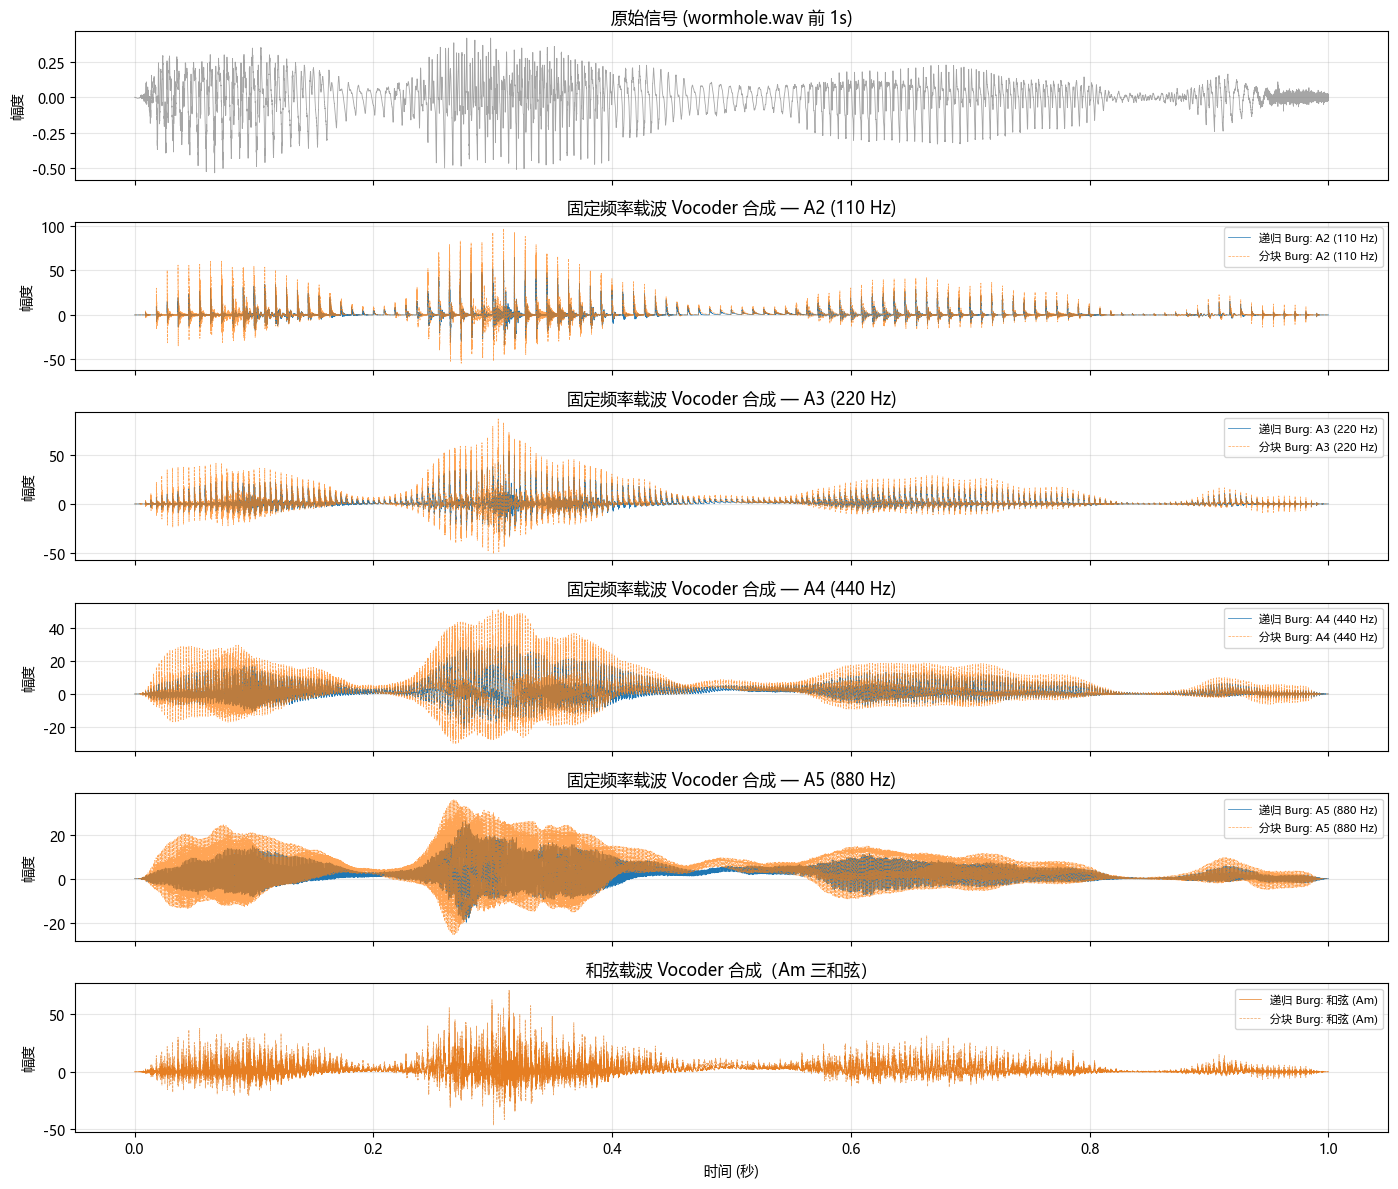

In [106]:
# ------------------------------------------------------------
# 14a. 波形对比：原始 vs 各固定频率载波合成
# ------------------------------------------------------------
n_freqs = len(test_freqs)
fig, axes = plt.subplots(n_freqs + 2, 1, figsize=(14, 12), sharex=True)

# 原始信号
ax0 = axes[0]
ax0.plot(t, x, color='gray', linewidth=0.6, alpha=0.7)
ax0.set_ylabel('幅度')
ax0.set_title('原始信号 (wormhole.wav 前 1s)')
ax0.grid(True, alpha=0.3)

# 各固定频率合成（递归 Burg 实线 + 分块 Burg 虚线）
for i, (label, _) in enumerate(test_freqs.items()):
    ax = axes[i + 1]
    synth = synth_fixed[label]
    synth_blk = synth_fixed_block[label]
    ax.plot(t, synth, linewidth=0.5, label=f'递归 Burg: {label}')
    ax.plot(t, synth_blk, linewidth=0.5, linestyle='--', alpha=0.7,
            label=f'分块 Burg: {label}')
    ax.set_ylabel('幅度')
    ax.set_title(f'固定频率载波 Vocoder 合成 — {label}')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

# 和弦合成
ax_last = axes[-1]
ax_last.plot(t, synth_chord, color='#e67e22', linewidth=0.5,
             label='递归 Burg: 和弦 (Am)')
ax_last.plot(t, synth_chord_block, color='#e67e22', linewidth=0.5,
             linestyle='--', alpha=0.7, label='分块 Burg: 和弦 (Am)')
ax_last.set_ylabel('幅度')
ax_last.set_title('和弦载波 Vocoder 合成（Am 三和弦）')
ax_last.set_xlabel('时间 (秒)')
ax_last.grid(True, alpha=0.3)

ax_last.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 15. 固定频率载波语谱图对比


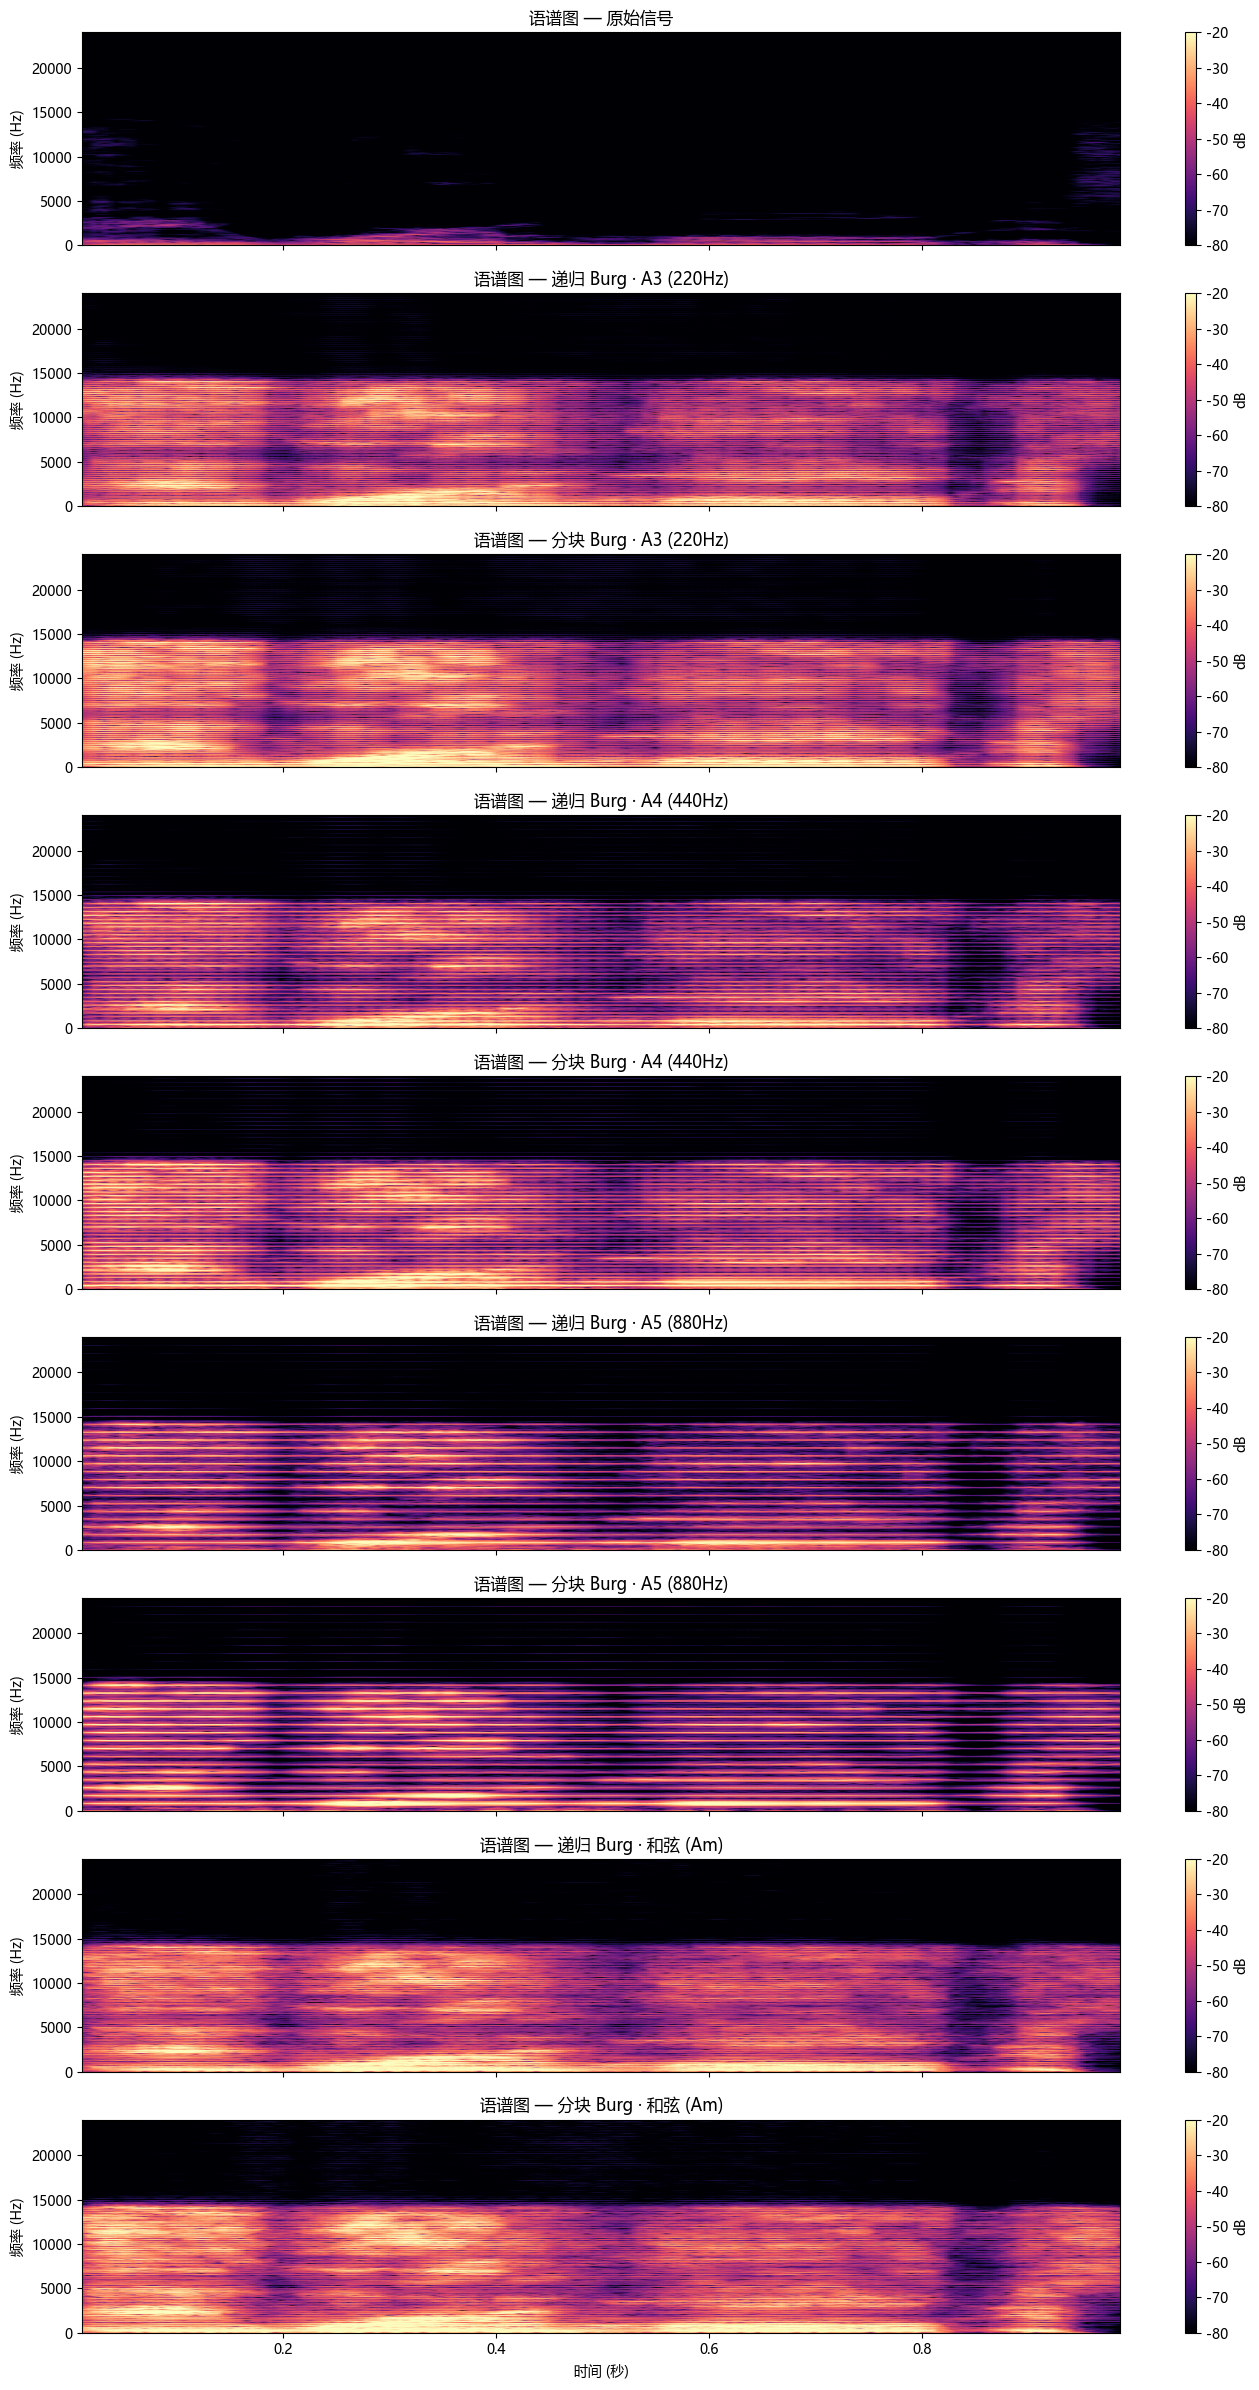

=== 频谱特征分析 ===
固定频率载波使谐波结构变为等间距梳状谱，间距 = 载波基频
同一 LPC 包络下，载波频率越高 → 谐波越稀疏 → 音色越 '亮'
和弦载波产生更丰富的谐波结构，接近乐器声码器的实际效果
分块 Burg vs 递归 Burg：分块法帧间系数跳变更大，频谱平滑度略差


In [107]:
# ------------------------------------------------------------
# 15a. 语谱图对比：原始 vs 不同频率载波合成 vs 和弦
# ------------------------------------------------------------
n_fft_spec = 1024
hop_len_spec = 256
vmin_db, vmax_db = -80, -20

# 选择对比的载波频率（递归 Burg + 分块 Burg）
spec_labels = {
    "原始信号": x,
    "递归 Burg · A3 (220Hz)": synth_fixed["A3 (220 Hz)"],
    "分块 Burg · A3 (220Hz)": synth_fixed_block["A3 (220 Hz)"],
    "递归 Burg · A4 (440Hz)": synth_fixed["A4 (440 Hz)"],
    "分块 Burg · A4 (440Hz)": synth_fixed_block["A4 (440 Hz)"],
    "递归 Burg · A5 (880Hz)": synth_fixed["A5 (880 Hz)"],
    "分块 Burg · A5 (880Hz)": synth_fixed_block["A5 (880 Hz)"],
    "递归 Burg · 和弦 (Am)": synth_chord,
    "分块 Burg · 和弦 (Am)": synth_chord_block,
}

fig, axes = plt.subplots(len(spec_labels), 1, figsize=(14, 24), sharex=True)

for idx, (label, signal) in enumerate(spec_labels.items()):
    ax = axes[idx]
    f_spec, t_spec, Sxx = spectrogram(signal, fs, nperseg=n_fft_spec,
                                       noverlap=n_fft_spec - hop_len_spec)
    Sxx_db = 10 * np.log10(Sxx + 1e-30)
    im = ax.pcolormesh(t_spec, f_spec, Sxx_db, shading='gouraud',
                       cmap='magma', vmin=vmin_db, vmax=vmax_db)
    ax.set_ylabel('频率 (Hz)')
    ax.set_title(f'语谱图 — {label}')
    ax.set_ylim(0, fs / 2)
    fig.colorbar(im, ax=ax, label='dB')

axes[-1].set_xlabel('时间 (秒)')
plt.tight_layout()
plt.show()

print("=== 频谱特征分析 ===")

print("固定频率载波使谐波结构变为等间距梳状谱，间距 = 载波基频")
print("同一 LPC 包络下，载波频率越高 → 谐波越稀疏 → 音色越 '亮'")
print("和弦载波产生更丰富的谐波结构，接近乐器声码器的实际效果")
print("分块 Burg vs 递归 Burg：分块法帧间系数跳变更大，频谱平滑度略差")

---
## 16. 载波信号细节对比


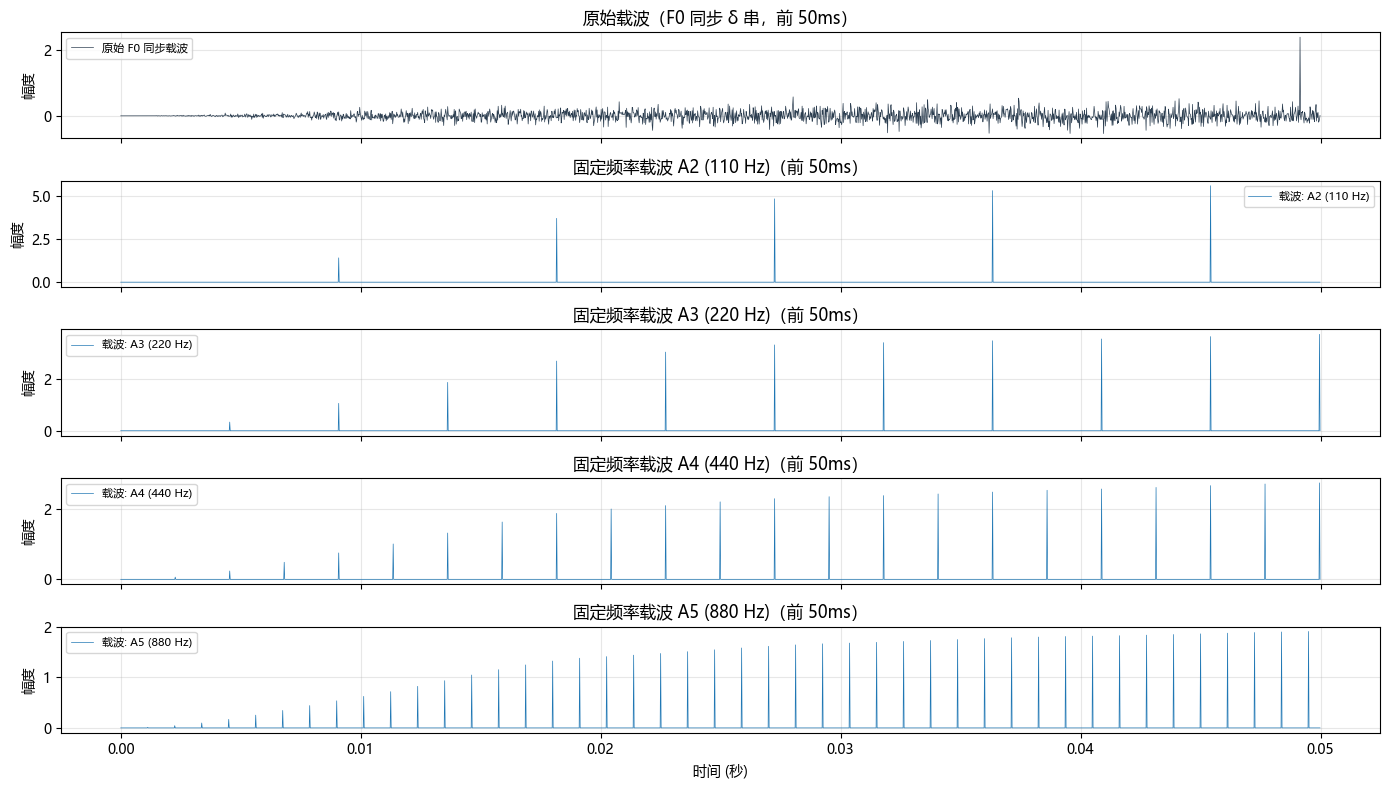

=== 载波特性对比 ===
原始 F0 同步载波: 0.0 脉冲/秒（平均）
固定频率 A2 (110 Hz): 0.0 脉冲/秒 = 110 Hz
固定频率 A3 (220 Hz): 0.0 脉冲/秒 = 220 Hz
固定频率 A4 (440 Hz): 0.0 脉冲/秒 = 440 Hz
固定频率 A5 (880 Hz): 0.0 脉冲/秒 = 880 Hz


In [108]:
# ------------------------------------------------------------
# 16a. 载波信号波形对比（前 50ms 放大查看）
# ------------------------------------------------------------
n_show = int(0.05 * fs)  # 50ms
t_show = t[:n_show]

fig, axes = plt.subplots(len(test_freqs) + 1, 1, figsize=(14, 8), sharex=True)

# 原始检测 F0 的载波
ax0 = axes[0]
ax0.plot(t_show, excitation[:n_show], color='#2c3e50', linewidth=0.5,
         label='原始 F0 同步载波')
ax0.set_ylabel('幅度')
ax0.set_title(f'原始载波（F0 同步 δ 串，前 50ms）')
ax0.grid(True, alpha=0.3)
ax0.legend(fontsize=8)

# 各固定频率载波
for i, (label, _) in enumerate(test_freqs.items()):
    ax = axes[i + 1]
    ax.plot(t_show, exc_fixed[label][:n_show], linewidth=0.5, label=f'载波: {label}')
    ax.set_ylabel('幅度')
    ax.set_title(f'固定频率载波 {label}（前 50ms）')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

axes[-1].set_xlabel('时间 (秒)')
plt.tight_layout()
plt.show()

# 统计各载波的脉冲密度
print("=== 载波特性对比 ===")
pulse_density_orig = np.sum(np.abs(excitation) > 0.1 * np.max(np.abs(excitation))) / N
print(f"原始 F0 同步载波: {pulse_density_orig:.1f} 脉冲/秒（平均）")
for label, freq in test_freqs.items():
    pd = np.sum(np.abs(exc_fixed[label]) > 0.1 * np.max(np.abs(exc_fixed[label]))) / N
    print(f"固定频率 {label}: {pd:.1f} 脉冲/秒 = {freq:.0f} Hz")


---
## 17. 固定频率载波音频播放对比

> ⚠️ 以下单元格包含 `display(Audio(...))`，运行后会播放音频。
> 请在需要听音对比时手动运行。


In [109]:
# ------------------------------------------------------------
# 17a. 音频播放 — 各固定频率载波合成对比（递归 + 分块 Burg）
# ------------------------------------------------------------
print("原始信号（前 1 秒）:")
display(Audio(x, rate=fs))

for label in test_freqs:
    s = synth_fixed[label]
    s_norm = s / (np.max(np.abs(s)) + 1e-30)
    print(f"固定频率载波 Vocoder — {label} [递归 Burg]:")
    display(Audio(s_norm, rate=fs))

    sb = synth_fixed_block[label]
    sb_norm = sb / (np.max(np.abs(sb)) + 1e-30)
    print(f"固定频率载波 Vocoder — {label} [分块 Burg]:")
    display(Audio(sb_norm, rate=fs))

print("和弦载波 Vocoder — Am (A3+C#4+E4) [递归 Burg]:")
synth_chord_norm = synth_chord / (np.max(np.abs(synth_chord)) + 1e-30)
display(Audio(synth_chord_norm, rate=fs))

print("和弦载波 Vocoder — Am (A3+C#4+E4) [分块 Burg]:")
synth_chord_block_norm = synth_chord_block / (np.max(np.abs(synth_chord_block)) + 1e-30)
display(Audio(synth_chord_block_norm, rate=fs))

原始信号（前 1 秒）:


固定频率载波 Vocoder — A2 (110 Hz) [递归 Burg]:


固定频率载波 Vocoder — A2 (110 Hz) [分块 Burg]:


固定频率载波 Vocoder — A3 (220 Hz) [递归 Burg]:


固定频率载波 Vocoder — A3 (220 Hz) [分块 Burg]:


...

固定频率载波 Vocoder — A4 (440 Hz) [分块 Burg]:


固定频率载波 Vocoder — A5 (880 Hz) [递归 Burg]:


固定频率载波 Vocoder — A5 (880 Hz) [分块 Burg]:


和弦载波 Vocoder — Am (A3+C#4+E4) [递归 Burg]:


和弦载波 Vocoder — Am (A3+C#4+E4) [分块 Burg]:
